In [1]:
# ==========================================
# 1. LOAD THE DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the uploaded CSV file
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [2]:
# ==========================================
# 2. SEPARATE FEATURES AND TARGET
# ==========================================

# Input features
X = df.drop("Outcome", axis=1)

# Target variable
y = df["Outcome"]

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print("Outcome")

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Input features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target variable:
Outcome

Shape of X: (768, 8)
Shape of y: (768,)


In [3]:
# ==========================================
# 3. IDENTIFY AND HANDLE INVALID VALUES
# ==========================================

# Check missing values
print("Missing values before processing:")
print(df.isnull().sum())

# Columns where zero is considered an invalid/missing measurement
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zeros before replacement
print("\nNumber of zero values before handling:")

for column in invalid_columns:
    print(column, ":", (df[column] == 0).sum())

# Replace zero values with NaN
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

# Check missing values after replacing zeros
print("\nMissing values after replacing invalid zeros:")
print(df.isnull().sum())

# Fill missing values with median
for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

# Check again
print("\nMissing values after median imputation:")
print(df.isnull().sum())

Missing values before processing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Number of zero values before handling:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0


In [4]:
# ==========================================
# 4. TRAIN-TEST SPLIT USING STRATIFICATION
# ==========================================

from sklearn.model_selection import train_test_split

# Separate X and y again after preprocessing
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (614, 8)
Testing data shape: (154, 8)

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [5]:
# ==========================================
# 5. FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Original training data:")
display(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22



Scaled training data:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40283188
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78237284
  -0.33762972 -0.96131967]]


In [6]:
# ==========================================
# 6. BUILD CLASSIFICATION MODELS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)

# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

print("Three classification models created:")
print("1. Logistic Regression")
print("2. K-Nearest Neighbors")
print("3. Decision Tree")

Three classification models created:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree


In [7]:
# ==========================================
# 7. TRAIN THE MODELS
# ==========================================

# Train Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

# Train KNN
knn_model.fit(X_train_scaled, y_train)

# Train Decision Tree
decision_tree_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [8]:
# ==========================================
# 8. GENERATE PREDICTIONS
# ==========================================

# Logistic Regression predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

# KNN predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Decision Tree predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 20 actual values:")
print(y_test.values[:20])

print("\nFirst 20 Logistic Regression predictions:")
print(y_pred_logistic[:20])

print("\nFirst 20 KNN predictions:")
print(y_pred_knn[:20])

print("\nFirst 20 Decision Tree predictions:")
print(y_pred_tree[:20])

Predictions generated successfully!

First 20 actual values:
[0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0]

First 20 Logistic Regression predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]

First 20 KNN predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]

First 20 Decision Tree predictions:
[1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0]


In [9]:
# ==========================================
# 9. CONFUSION MATRICES
# ==========================================

from sklearn.metrics import confusion_matrix

# Calculate confusion matrices
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

print("\nKNN Confusion Matrix:")
print(cm_knn)

print("\nDecision Tree Confusion Matrix:")
print(cm_tree)

Logistic Regression Confusion Matrix:
[[82 18]
 [27 27]]

KNN Confusion Matrix:
[[83 17]
 [21 33]]

Decision Tree Confusion Matrix:
[[78 22]
 [15 39]]


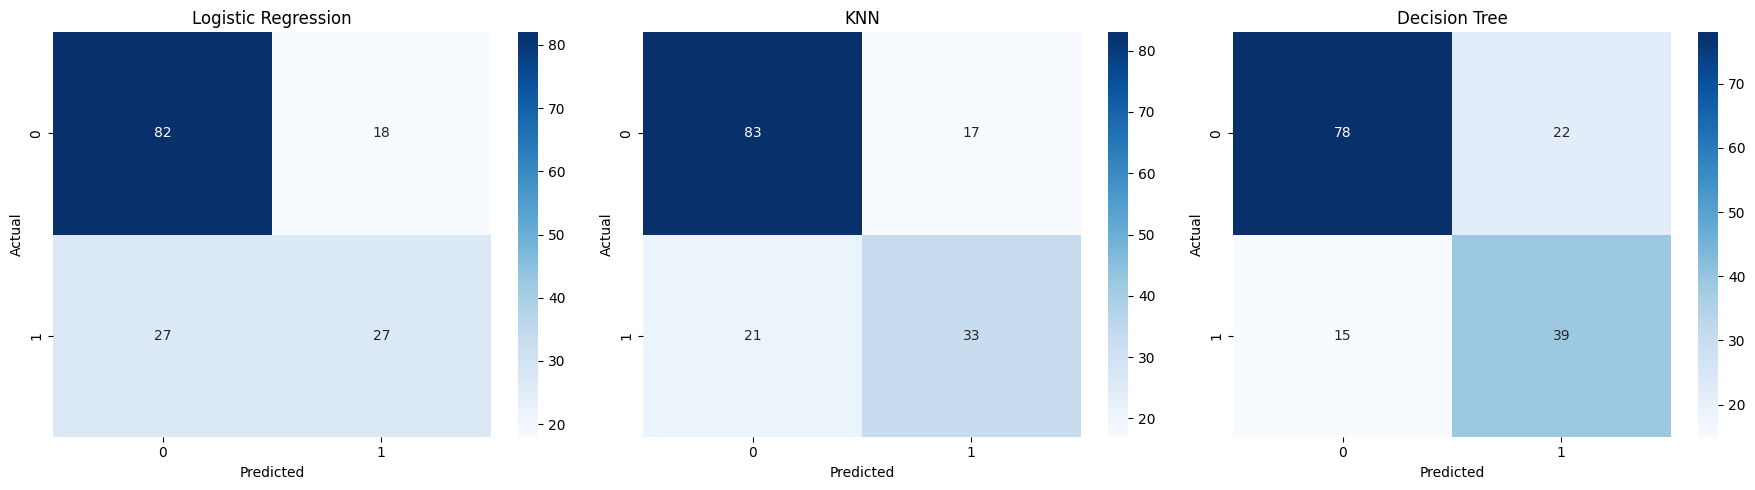

In [10]:
# ==========================================
# VISUALIZE CONFUSION MATRICES
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2]
)
axes[2].set_title("Decision Tree")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [11]:
# ==========================================
# 10. CLASSIFICATION PERFORMANCE METRICS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Function to calculate metrics
def calculate_metrics(model_name, y_true, y_pred, y_probability):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_probability)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }


# Probability predictions
logistic_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]
knn_probability = knn_model.predict_proba(X_test_scaled)[:, 1]
tree_probability = decision_tree_model.predict_proba(X_test)[:, 1]


# Calculate metrics
results = []

results.append(
    calculate_metrics(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        logistic_probability
    )
)

results.append(
    calculate_metrics(
        "KNN",
        y_test,
        y_pred_knn,
        knn_probability
    )
)

results.append(
    calculate_metrics(
        "Decision Tree",
        y_test,
        y_pred_tree,
        tree_probability
    )
)


# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,KNN,0.753247,0.660000,0.611111,0.634615,0.788611
2,Decision Tree,0.759740,0.639344,0.722222,0.678261,0.762222


In [12]:
# ==========================================
# CLASSIFICATION REPORTS
# ==========================================

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_logistic))


print("=" * 60)
print("K-NEAREST NEIGHBORS")
print("=" * 60)
print(classification_report(y_test, y_pred_knn))


print("=" * 60)
print("DECISION TREE")
print("=" * 60)
print(classification_report(y_test, y_pred_tree))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

K-NEAREST NEIGHBORS
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154

DECISION TREE
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0

In [13]:
# ==========================================
# 11. MODEL COMPARISON AND INTERPRETATION
# ==========================================

# Sort models by F1-score
comparison = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("Models ranked according to F1-Score:")
display(comparison)

# Best model
best_model = comparison.iloc[0]

print("\nBest performing model based on F1-Score:")
print(best_model["Model"])

print("\nPerformance:")
print("Accuracy :", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall   :", round(best_model["Recall"], 4))
print("F1-Score :", round(best_model["F1-Score"], 4))
print("ROC-AUC  :", round(best_model["ROC-AUC"], 4))

Models ranked according to F1-Score:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Decision Tree,0.759740,0.639344,0.722222,0.678261,0.762222
1,KNN,0.753247,0.660000,0.611111,0.634615,0.788611
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963



Best performing model based on F1-Score:
Decision Tree

Performance:
Accuracy : 0.7597
Precision: 0.6393
Recall   : 0.7222
F1-Score : 0.6783
ROC-AUC  : 0.7622
